https://www.kaggle.com/datasets/larsen0966/penguins/data

In [92]:
import pandas as pd
data = pd.read_csv('penguins.csv')

In [93]:
import seaborn as sb
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

corr_matrix = data.corr(numeric_only = True)
corr_matrix

,Unnamed: 0,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
Unnamed: 0,1.000000,0.766039,-0.259563,0.455372,0.275493,0.339103
bill_length_mm,0.766039,1.000000,-0.235053,0.656181,0.595110,0.054545
bill_depth_mm,-0.259563,-0.235053,1.000000,-0.583851,-0.471916,-0.060354
flipper_length_mm,0.455372,0.656181,-0.583851,1.000000,0.871202,0.169675
body_mass_g,0.275493,0.595110,-0.471916,0.871202,1.000000,0.042209
year,0.339103,0.054545,-0.060354,0.169675,0.042209,1.000000


<Axes: >

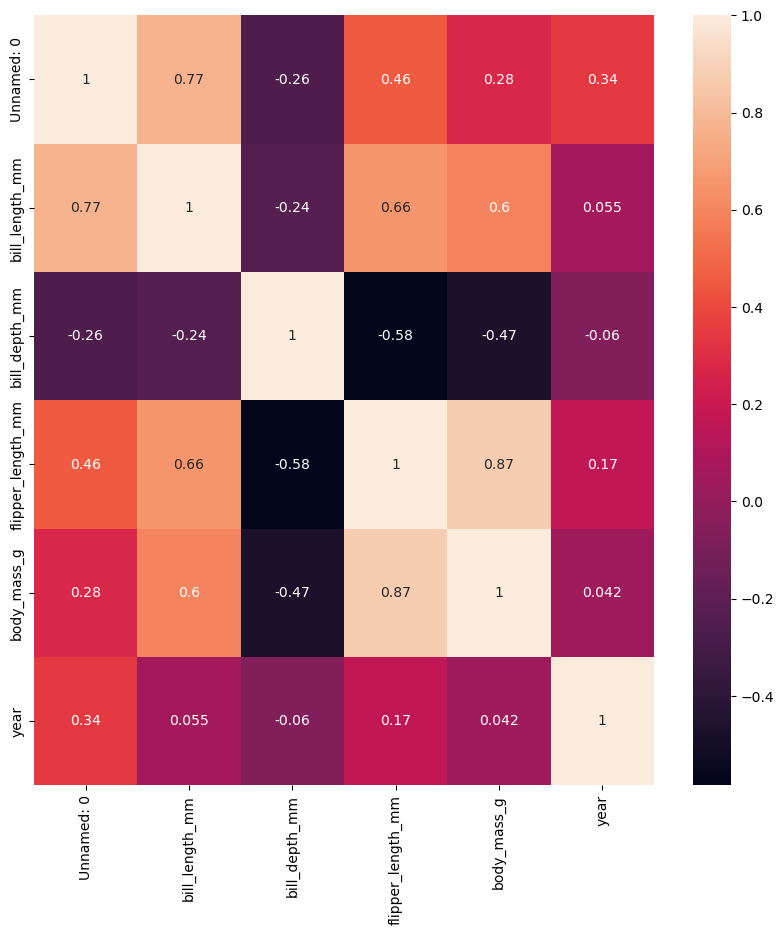

In [94]:
fig, ax = plt.subplots(figsize=(10,10))
sb.heatmap(corr_matrix, annot=True)

In [95]:
data_copy = data.copy()
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [96]:
data_copy.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [97]:
categorical_cols = [
    'species', 
    'island',
    'sex'
]
numerical_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'year'
]

In [98]:
data_copy.isna().sum()

Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [99]:
sex = {'male':0, 'female':1}

In [100]:
data_copy["sex"] = data_copy["sex"].map(sex)

data_copy.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,0.0,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,1.0,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,1.0,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,1.0,2007


In [101]:
data_copy["sex"].value_counts()

sex
0.0    168
1.0    165
Name: count, dtype: int64

In [102]:
sex_mean = data_copy["sex"].mean()
data_copy["sex"] = data_copy["sex"].fillna(sex_mean)
data_copy.isna().sum()

Unnamed: 0           0
species              0
island               0
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
sex                  0
year                 0
dtype: int64

In [103]:
d = data_copy.dropna(subset='bill_length_mm')
d.isna().sum()

Unnamed: 0           0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

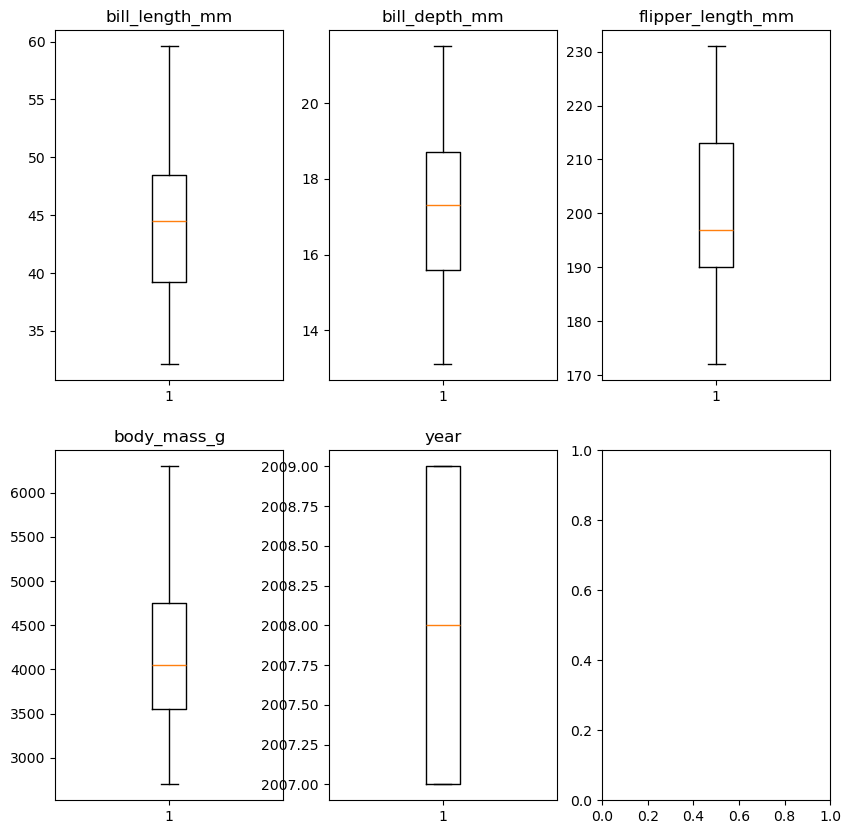

In [104]:
for ax, col_name in zip(plt.subplots(2,3, figsize=(10, 10))[1].flatten(), numerical_cols):
    ax.set_title(col_name)
    ax.boxplot(d[col_name])

In [105]:
d['island'].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

In [106]:
island = {'Biscoe':0, 'Dream':1, 'Torgersen':2}

In [107]:
d["island"] = d["island"].map(island)

C:\Users\r4yte\AppData\Local\Temp\ipykernel_27864\934418731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["island"] = d["island"].map(island)


In [108]:
d["island"].value_counts()

island
0    167
1    124
2     51
Name: count, dtype: int64

In [109]:
d["species"].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [110]:
species = {'Adelie':0, 'Gentoo':1, 'Chinstrap':2}

In [111]:
d["species"] = d["species"].map(species)

C:\Users\r4yte\AppData\Local\Temp\ipykernel_27864\1276659538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["species"] = d["species"].map(species)


In [112]:
d["species"].value_counts()

species
0    151
1    123
2     68
Name: count, dtype: int64

In [113]:
X = d.drop(columns="species")
Y = d["species"]

In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

In [115]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(5)

In [116]:
knn.fit(X_train, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [117]:
pred_train = knn.predict(X_train)

In [118]:
pred = knn.predict(X_test)
pred

array([0, 0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 0, 0, 1, 2, 1, 0, 0, 2, 0, 2,
       2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 2, 1, 1, 1, 2, 2, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 2, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 2, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0])

In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Accuracy", accuracy_score(Y_test, pred))
print("Precision", precision_score(Y_test, pred, average="macro"))
print("Recall", recall_score(Y_test, pred, average="macro"))

Accuracy 0.9767441860465116
Precision 0.9814241486068113
Recall 0.9583333333333334


Единственное, что я в целом понял про этот датасет, так это его приятные для работы данные. Здесь есть оч много ситуаций, на которых можно освоить разные способы, как превратить категориальные данные в числа, которые поймет мой алгоритм (One-hot encoding, к примеру), что очень помогает запомнить материал. Так же, здесь есть очень сильная корреляция между длиной ласт и массой тела, что в целом даёт на примере понять, что это вообще такое.

Никаких наблюдений особо нет 😭, очень хорошие данные (даже выбросов нет, пингвины все среднячковые такие)

Следующим я бы хотел взять датасет с НЛО (https://www.kaggle.com/datasets/NUFORC/ufo-sightings), очень он интересный, единственное, я забыл оч многие инструменты для подготовки данных к обучению, так что пришлось его отложить. Из интересного, я брал датасет с отзывами на игру Apex Legends в стиме, где были наигранные часы за всё время, за последние две недели, текст пользователя и оценка (нравится или нет). Надо было научить алгоритм предсказывать, понравилась ли игра пользователю или нет.

У ИИ я спросил за боксплот, потому что спустя время мне этот ящик с усами позабылся и показался оч странным 😭, и пару уточнений за One-hot encoding и метрики для результата, все остальное было в конспекте и чуть в памяти. Почти всё написано руками